# 26 Weekly DMOs -> Fatigue

In [31]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.pipeline import dmo_for_random_forest
from src.model import DMORandomForestRegressor
from src.evaluation import Evaluation

import torch

In [32]:
dmo_features = [
    "cadence_30_p90",
    "cadence_30_avg",
    "ws_30_p90",
    "strlen_1030_avg",
    "cadence_all_avg",
]

In [33]:
static_features = [
    "weight",
    "height",
    "EDFSCR1L"
]

In [34]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    filtered=True,
    static_features=static_features,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [35]:
print(dmo_data.shape)

torch.Size([593, 5, 7, 8])


In [36]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherf

In [37]:
print(dmo_data.shape)

torch.Size([593, 5, 7, 8])


In [38]:
# remove patients that don't have a full dataset
patient_indexs = []
patients, visits, features, days = dmo_data.shape
for p in range(patients):
    all_visits = True
    for v in range(visits):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [39]:
# flatten to weekly summaries (this keeps patients consistant over the testing)
dmo_data = dmo_data.mean(axis=2)

In [40]:
patients, visits, features = dmo_data.shape
updated_dmo_data = torch.zeros(patients, visits - 1, features + 1)
for p in range(patients):
    features = dmo_data[p, 1:]
    labels = dmo_labels[p, :-1]

    updated_dmo_data[p] = torch.concatenate((features, labels), axis=1)

dmo_data = updated_dmo_data
print(dmo_labels.shape)
print(dmo_data.shape)


torch.Size([254, 5, 1])
torch.Size([254, 4, 9])


In [41]:
dmo_labels = dmo_labels[:, 1:, :]
print(dmo_labels.shape)

torch.Size([254, 4, 1])


In [42]:
transforms = (None, None)
train, test = dmo_for_random_forest(dmo_data, dmo_labels, transforms)

train_input, train_label = train
test_input, test_label = test

In [43]:
patient, visit, features = train_input.shape
train_input = train_input.reshape(patient * visit, features)
train_label = train_label.reshape(patient * visit)

patient, visit, features = test_input.shape
test_input = test_input.reshape(patient * visit, features)
test_label = test_label.reshape(patient * visit)

In [44]:
rf_model = DMORandomForestRegressor(n_trees=500)

rf_model.train(train_input, train_label)


{'accuracy': 0.0, 'Mean Squared Error': 141.26869201660156, 'Mean Absolute Error': 9.687470436096191, 'R^2': 0.4073858833665507}


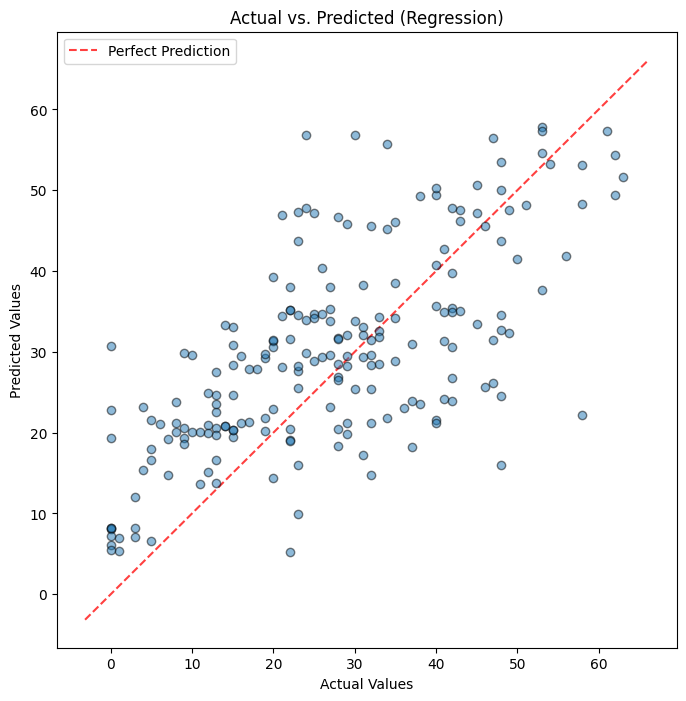

In [45]:
prediction = torch.tensor(rf_model.predict(test_input))
actual = test_label
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()